# Properties of dimensionality reduction methods in the estimation of linear regression models in the presence of multicollinearity

The purpose of the project is the analysis of properties of dimensionality reduction methods, such as **Principal Component Regression (PCR) and Partial Least Squares Regression (PLSR)**, in the estimation of linear regression models under different levels of approximate multicollinearity among the explanatory variables. 
The objective of the analysis is:
* the examination the properties of the structural parameters estimators obtained using the above-mentioned methods in various conditions, 
* the comparison of the models' goodness of fit and generalization abilities,
* the comparison of the obtained results with the properties of an OLS model. 

In order to analyze various conditions under which a linear regression model could be estimated, analyses were conducted using **simulated data**. Generated datasets vary in:
* sizes, 
* sets of used explanatory variables, 
* strength of correlation between them
* sets of structural parameters' true values.

Based on these datasets, estimation of the linear regression models was conducted using 3 methods: PCR, PLSR and OLS. Then the properties of the obtained models were studied. 

In [84]:
import sys 
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
sys.path.append("../src")
from functions import plot_bias, plot_sd, plot_sign_accuracy, plot_metrics_heatmap, wrapper_bias, wrapper_sd, wrapper_sign_accuracy, wrapper_heatmap, plot_collinearity_summary

# 1. Data

In [85]:
with open("simulated_data.pkl", "rb") as f:
    df = pickle.load(f)

In [86]:
best_ratio = 0.6

In [87]:
sample_sizes = [50, 500]
rhos = [0.2, 0.6, 0.8, 0.95]
components_ratios = [0.5, 0.6, 0.7, 0.8, 0.9]
scenarios = ["baseline", "extra_vars", "omitted_vars"]
betas_list = [
    [1,1,1,1,1],
    [5,0.5,0.5,0.5,0.5],
    [3,-3,3,-3,3],
    [1,2,3,4,5]
]

# 2. Multicollinearity assesment - VIF and CI

Multicollinearity can manifest itself in many ways. In this project, the case of multicollinearity in a form of high correlations between pairs of variables was analyzed. However, it is important to note that the terms of multicollinearity and correlation are not equivalent. Therefore, in this section the degree of multicollinearity in the generated datasets is examined by Variance Inflation Factor (VIF) and Condition Index (CI) measures. 

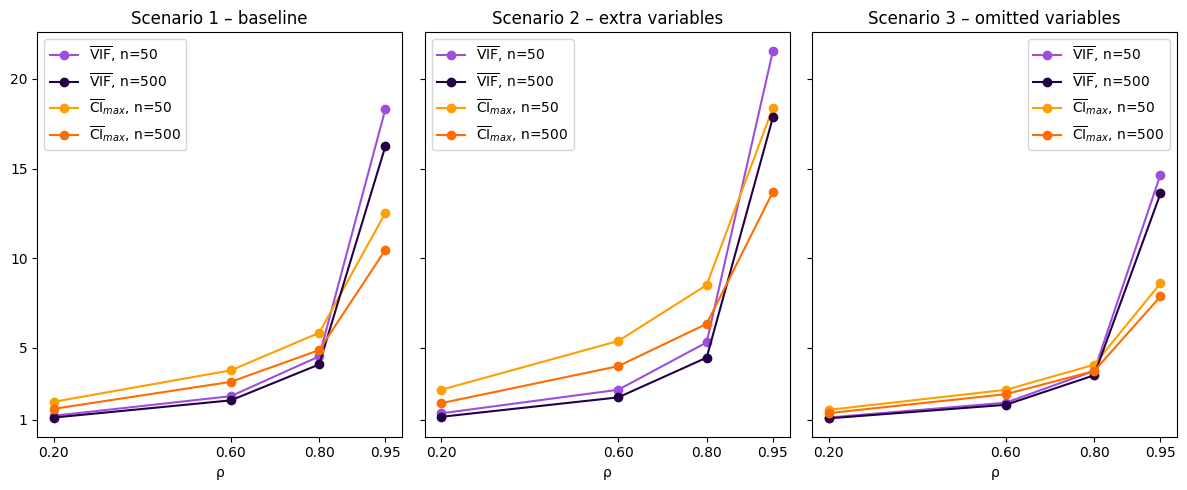

In [88]:
plot_collinearity_summary(df, scenarios, sample_sizes, rhos)

Moderate multicolliearity can be detected by VIF in range 1-5 or CI over 15. Strong multicollinearity is associated with VIF over 5 or CI over 30.  
The analysis of the plots suggests a presence of:
* very strong multicollinearity in case of $\rho$ = 0.95
* moderate multicollinearity in case of $\rho$ = 0.8.
* very weak multicollinearity in case of $\rho$ = 0.6 or $\rho$ = 0.2.

# 3. Estimator properties analysis
## 3.1. Bias analysis

Firstly, an analysis of the OLS, PCR and PLSR estimators' bias was performed. Plots show the relationships between the absolute value of bias and the proportion of variance explained by the PCR components. To ensure the comparability of the results, the number of latent variables used in the PLSR method is equal to the number of PCR components, explaining the given variance proportion. The absolute value of bias, instead of the original value, was presented in order to analyze its magnitude, regardless of its sign. 

In [89]:
wrapper_bias(df)

interactive(children=(Dropdown(description='scenario', options=('baseline', 'extra_vars', 'omitted_vars'), val…

Presented plots allow to observe the following patterns:
* OLS estimators are unbiased, regardless of the multicollinearity degree. On the contrary, the PCR and PLSR methods generally introduce substantial estimation bias, at times ranging to even 100-400% of the true parameter value. 
* The selected number of components/latent variables impacts the estimation in case of weaker correlations. In case of very high correlations it does not impact the results significantly. 
* In general, PLSR allows for less biased estimations than PCR, especially in case of lower correlations. 
* In the scenario with omitted variables, the bias of estimators is varied. The properties of PCR and PLSR estimators are varied among the parameters. 

## 3.2. Standard deviation analysis

In the next step, the standard deviation of the estimators was analyzed.

In [90]:
wrapper_sd(df)

interactive(children=(Dropdown(description='scenario', options=('baseline', 'extra_vars', 'omitted_vars'), val…

* Application of PCR and PLSR methods allows to reduce the standard deviations of estimators especially in 2 cases:
    * very strong correlation,
    * strong correlation and small sample.  
In those scenarios, the dimensionality reduction methods might improve the precision of the estimators while introducting bias (variance-bias payoff).
* PLSR method is more universal than the PCR method, as it allows for precise estimation both in case of weak and strong multicollinearity. 
* In the baseline model, it is recommended to use the number of components covering no more than 0.6 of the variance. Using too many components/latent variables might result in a sudden drop of the precision. 
* In case of extra or omitted variables, the benefits of implementing PCR and PLSR are especially visible. It suggests that dimensionality reduction methods might be beneficial especially in case of model misspecification. 


## 3.3. Sign accuracy analysis

In the next step, proportion of correctly estimated coefficient signs was studied, in order to evaluate how effectively each method predicted the directions of the relationships between the predictors and the target variable. 

In [91]:
wrapper_sign_accuracy(df)

interactive(children=(Dropdown(description='scenario', options=('baseline', 'extra_vars', 'omitted_vars'), val…

* When all real signs of the coefficients are consistent (all positive or all negative), PLSR method allows to almost perfectly assess the signs of the coefficients. As mentioned earlier, in this case the estimators are biased, but the directions of the relationships are reflected correctly. The PLSR method gives more or at least as accurate sign estimations as the OLS method. 
* PLSR method is more universal than PCR method - it allows for accurate estimation in more versatile conditions, such as weaker multicollinearity.
* Dimensionality reduction methods are especially effective in case of small sample and high or very high correlation. 
* However, in case of varying coefficient signs, the accuracy of PCR and PLSR methods is lower than the OLS method. 

## 3.4. Goodness of fit and generalization analysis

In the final section, the goodness of fit and generalization abilities of the estimated models was analyzed. The fitness to the training set was evaluated using the adjusted $R^2$. Furthermore, the predictive abilities on the test set were assessed using mean squared error acquired through cross-validation.  
Based on the results from the previous sections, in the PCR method the number of components explaining 60% of the variance was used. In the PLSR method, the number of latent variables equaled the number of PCR components. The following plots depict the mean values of the mentioned measures from 1000 simulations.

In [92]:
wrapper_heatmap(df)

interactive(children=(Dropdown(description='scenario', options=('baseline', 'extra_vars', 'omitted_vars'), val…

* The dimensionality reduction methods do not improve the predictive and generalization abilities of the regression model. Such a pattern is understandable - multicollinearity does not affect the model's goodness of fit, so the OLS model which receives full information from the explaining variables performs better. 
* However, if the dimensionality reduction methods are used, PLSR performs better than PCR. It is because in the PLSR method, while constructing the latent variables, information about the covariance between y and X variables is considered. 

# 4. Conclusions

The analysis allowed to outline the properties of the PCR and PLSR methods in terms of the bias, variance, sign accuracy and model's goodness of fit, depending on the size of the sample, the degree of multicollinearity and number of variables used. Based on these properties, the following recommendations can be formed:
* The dimensionality reduction methods allow to reduce the variation of the estimators at the cost of introducing bias (bias-variance tradeoff). 
* The precision of the estimation can be improved by these methods especially in 2 particular cases: 
    * very high correlation between variables,
    * high correlation between variables and small sample size.
* PCR and PLSR methods perform very similarly in case of strong mutlicollinearity. However, in case of weaker correlations, PLSR method is generally more effective than the PCR method, which sometimes performs even worse than the OLS method. Therefore, the PLSR method is more universal and effective. 
* Benefits from implementing the dimensionality reduction methods occur when the number of explaining variables is appropriately reduced. It is recommended to use the number of variables explaining no more than 60-70% of variance. Using too many components or latent variables might even result in degredation of model performance in comparison to the OLS method. 
* PLSR method allows to accurately estimate the directions of the relationships between the variables, only when real parameter signs are constistent. Therefore, this method is recommended when expertise or prior knowledge indicates consistent parameter signs. 
* The dimensionality reduction methods do not improve the predictive abilities of the model. However, if based on other factors these methods are to be implemented, it is recommended to use the PLSR method instead of PCR.